📊 RESULTADOS DE LA PRUEBA CHI-CUADRADO DE MÁXIMA VEROSIMILITUD 📊

🔹 Prueba de Chi-cuadrado de la Tasa de Verosimilitud:
   - Estadístico G²: 0.138
   - P-valor: 0.71069
   - Grados de libertad: 1

📌 CONCLUSIÓN:
❌ Tasa de Verosimilitud: No hay suficiente evidencia para concluir que el tipo de prueba influye.

🔹 Tabla de Frecuencias Esperadas (bajo H0, Verosimilitud):
           A tiempo      Tarde
Mejorada  44.666667   5.333333
Normal    89.333333  10.666667


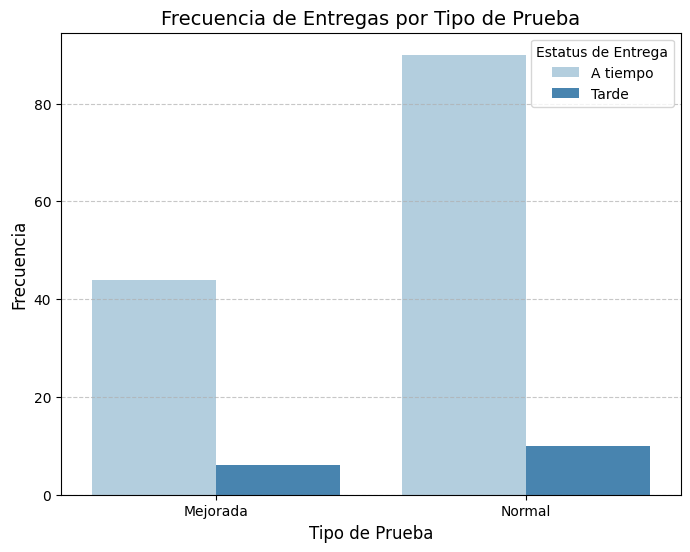

In [7]:
# 📌 Instalamos las librerías necesarias en caso de que no estén disponibles
!pip install numpy pandas scipy statsmodels matplotlib seaborn

# 📌 Importamos las librerías necesarias
import numpy as np  # Para manejo de arreglos numéricos
import pandas as pd  # Para manejo y análisis de datos en tablas
import scipy.stats as stats  # Para realizar la prueba de chi-cuadrado
import matplotlib.pyplot as plt  # Para visualización de datos
import seaborn as sns  # Para gráficos más estilizados

# 📌 Definir la tabla de contingencia con los valores exactos
observed = np.array([
    [44, 6],  # Mejorada (A tiempo, Tarde)
    [90, 10]  # Normal (A tiempo, Tarde)
])

# 📌 Calcular totales
row_totals = observed.sum(axis=1)  # Suma por filas
col_totals = observed.sum(axis=0)  # Suma por columnas
grand_total = observed.sum()  # Total general

# 📌 Calcular la tabla de frecuencias esperadas bajo H0
expected = np.outer(row_totals, col_totals) / grand_total

# 📌 Prueba de Chi-cuadrado de la Tasa de Verosimilitud (log-likelihood)
G_stat = 2 * np.sum(observed * np.log(observed / expected))
dof = (observed.shape[0] - 1) * (observed.shape[1] - 1)  # Grados de libertad
p_value_likelihood = 1 - stats.chi2.cdf(G_stat, df=dof)  # P-valor

# 📌 Convertimos la tabla de frecuencias esperadas en un DataFrame
tabla_esperada = pd.DataFrame(expected, columns=["A tiempo", "Tarde"], index=["Mejorada", "Normal"])

# 📌 Mostramos los resultados ajustados con cálculos manuales
print("📊 RESULTADOS DE LA PRUEBA CHI-CUADRADO DE MÁXIMA VEROSIMILITUD 📊")

print("\n🔹 Prueba de Chi-cuadrado de la Tasa de Verosimilitud:")
print(f"   - Estadístico G²: {G_stat:.3f}")
print(f"   - P-valor: {p_value_likelihood:.5f}")
print(f"   - Grados de libertad: {dof}")

# 📌 Interpretación del resultado
alpha = 0.05  # Nivel de significancia (5%)

print("\n📌 CONCLUSIÓN:")
if p_value_likelihood < alpha:
    print("✅ Tasa de Verosimilitud: Rechazamos H0, existe una relación significativa.")
else:
    print("❌ Tasa de Verosimilitud: No hay suficiente evidencia para concluir que el tipo de prueba influye.")

# 📌 Mostramos la tabla de frecuencias esperadas
print("\n🔹 Tabla de Frecuencias Esperadas (bajo H0, Verosimilitud):")
print(tabla_esperada)

# 📌 Visualización de los datos en un gráfico de barras
df_visual = pd.DataFrame({
    "Tipo de Prueba": ["Mejorada", "Mejorada", "Normal", "Normal"],
    "Estatus": ["A tiempo", "Tarde", "A tiempo", "Tarde"],
    "Frecuencia": [44, 6, 90, 10]
})

plt.figure(figsize=(8, 6))
sns.barplot(x="Tipo de Prueba", y="Frecuencia", hue="Estatus", data=df_visual, palette="Blues")

# 📌 Personalizamos el gráfico
plt.title("Frecuencia de Entregas por Tipo de Prueba", fontsize=14)
plt.xlabel("Tipo de Prueba", fontsize=12)
plt.ylabel("Frecuencia", fontsize=12)
plt.legend(title="Estatus de Entrega")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


